In [ ]:
!pip install gdown matplotlib pandas seaborn scikit-learn xgboost -q

In [ ]:
import os

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb



In [ ]:
plt.style.use('fivethirtyeight')
sns.set_palette('husl')

# Utility Functions

In [ ]:
def sort_and_index_timestamp(df):
    """Sort timestamp"""
    UNIX_EPOCH_START_TICKS = 621355968000000000
    df['timestamp'] = pd.to_datetime(
        (df['timestamp'] - UNIX_EPOCH_START_TICKS) * 100,
        unit='ns'
    )
    df = df.set_index('timestamp')
    return df

def pp(item=None):
    """Pretty print"""
    if not bool(item):
        print("\n\n")
        return
    print(f"{'='*20}   {item}   {'='*20}")

def evaluate_model(y_true, y_pred, model_name="Model"):
    """Calculate and display regression metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        accuracy = 100 - mape
    else:
        mape = np.nan
        accuracy = np.nan

    pp(f"{model_name} Performance Metrics")
    pp(f"R² Score:       {r2:.6f}")
    pp(f"RMSE:           {rmse:.6f} tons/hour")
    pp(f"MAE:            {mae:.6f} tons/hour")
    pp(f"MAPE:           {mape:.4f}%")
    pp(f"Accuracy:       {accuracy:.4f}%")

    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape, 'accuracy': accuracy}

# Dataset Grab

In [ ]:
data_dir = "datasets___"
os.makedirs(data_dir, exist_ok=True)

if not os.listdir(data_dir):
    pp("Downloading datasets...")
    gdown.download_folder(
        "https://drive.google.com/drive/folders/13gXlq0M-BHJiVpZkLnpHFN0Snh7N16St",
        output=data_dir,
        quiet=False
    )
else:
    pp("Datasets already available")

file_mapping = {
    'fuel_density': 'fuelDensity.csv',
    'fuel_temp': 'fuelTemp.csv',
    'fuel_flow': 'fuelVolumeFlowRate.csv',
    'inclinometer': 'inclinometer-raw.csv',
    'latitude': 'latitude.csv',
    'longitude': 'longitude.csv',
    'level1': 'level1median.csv',
    'level2': 'level2median.csv',
    'water_speed': 'longitudinalWaterSpeed.csv',
    'port_pitch': 'portPitch.csv',
    'port_rudder': 'portRudder.csv',
    'speed_kmh': 'speedKmh.csv',
    'speed_knots': 'speedKnots.csv',
    'starboard_pitch': 'starboardPitch.csv',
    'starboard_rudder': 'starboardRudder.csv',
    'track_mag': 'trackDegreeMagnetic.csv',
    'track_true': 'trackDegreeTrue.csv',
    'heading': 'trueHeading.csv',
    'wind_angle': 'windAngle.csv',
    'wind_speed': 'windSpeed.csv'
}


====================   Downloading datasets...   ====================


Retrieving folder contents


Processing file 1NIG2gG4kifMEoKvBeP8NQRQCGsY_sS1m fuelDensity.csv
Processing file 18BermqQ-lgfGM6gbCBPbQo9zstvOvP5n fuelTemp.csv
Processing file 1maSa0a3tCho2-Y9Y1vPLsewbntJY25R_ fuelVolumeFlowRate.csv
Processing file 1ZfZn1W__7EnpLDyMePfGZnvEwEA68PA_ inclinometer-raw.csv
Processing file 1MT2EDBElo1se7ae5dladmSigs89ITgnv latitude.csv
Processing file 1c626WNFtGtaGwfPMYe4SoVc-gkun1n_2 level1median.csv
Processing file 1N4Er7TzmGeDV9RUsr8zXLaJHNls6fSKw level2median.csv
Processing file 1OJhnUee8oNzQzQPhG_n9adDR2SXRdZEw longitude.csv
Processing file 1bf5Tab6y9s22oacAanI8tDy5fc_LXrCl longitudinalWaterSpeed.csv
Processing file 11wm2NAbQwzds13XO1Jmo4xXvzQbJ95uW portPitch.csv
Processing file 1waR67gZAn56vJuJHtty7wxkeilWqo0Tf portRudder.csv
Processing file 1HpHHuonoQlxss_5lyAFH3y40qmUiI45p speedKmh.csv
Processing file 1Hfij8CVPGIoL-TKudAQdjSSozpB4Lt9a speedKnots.csv
Processing file 1SAPEMtRQEwXbzMIF8cL2DKU9Y_8x4fA- starboardPitch.csv
Processing file 1vybameG_KTRFYUSR9XlKLKuxTXvsvp3p starboardRudd

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NIG2gG4kifMEoKvBeP8NQRQCGsY_sS1m
To: /content/datasets___/fuelDensity.csv
100%|██████████| 47.0M/47.0M [00:00<00:00, 130MB/s]
Downloading...
From: https://drive.google.com/uc?id=18BermqQ-lgfGM6gbCBPbQo9zstvOvP5n
To: /content/datasets___/fuelTemp.csv
100%|██████████| 45.4M/45.4M [00:00<00:00, 105MB/s]
Downloading...
From: https://drive.google.com/uc?id=1maSa0a3tCho2-Y9Y1vPLsewbntJY25R_
To: /content/datasets___/fuelVolumeFlowRate.csv
100%|██████████| 47.0M/47.0M [00:00<00:00, 88.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZfZn1W__7EnpLDyMePfGZnvEwEA68PA_
To: /content/datasets___/inclinometer-raw.csv
100%|██████████| 92.3M/92.3M [00:00<00:00, 154MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MT2EDBElo1se7ae5dladmSigs89ITgnv
To: /content/datasets___/latitude.csv
100%|██████████| 80.3M/80.3M [00:00<00:00, 80

In [ ]:
def load_and_resample_sensor(column_name, resample_rate='1h'):
    """Load sensor data and resample to specified frequency"""
    file = file_mapping[column_name]
    pp(f"Loading {column_name}...")
    file_path = f"{data_dir}/{file}"

    df = pd.read_csv(
        file_path,
        header=None,
        names=["timestamp", column_name]
    )

    df = sort_and_index_timestamp(df)

    pp(f"  Raw data points: {len(df)}")
    pp(f"  Date range: {df.index.min()} to {df.index.max()}")

    resampled = df[column_name].resample(resample_rate).mean()

    pp(f"After resampling: {len(resampled)} points")
    pp(f"Missing values: {resampled.isna().sum()} ({resampled.isna().sum()/len(resampled)*100:.1f}%)")

    return resampled


In [ ]:
for file in os.listdir(data_dir):
    file_path = f'{data_dir}/{file}'
    name = file.replace('.csv', '').strip()
    df = pd.read_csv(
        file_path,
        header=None,
        names=["timestamp", name]
    )
    print(f"{name} - {df.shape}")

longitudinalWaterSpeed - (548292, 2)
fuelTemp - (1627324, 2)
latitude - (2677713, 2)
windSpeed - (863755, 2)
starboardPitch - (1726076, 2)
fuelVolumeFlowRate - (1627324, 2)
portRudder - (1726076, 2)
trackDegreeMagnetic - (1766474, 2)
portPitch - (1726076, 2)
speedKnots - (1766908, 2)
level1median - (3979774, 2)
level2median - (3840794, 2)
starboardRudder - (1726076, 2)
trueHeading - (1439539, 2)
fuelDensity - (1627324, 2)
trackDegreeTrue - (1766479, 2)
longitude - (2677696, 2)
speedKmh - (1766906, 2)
windAngle - (863755, 2)
inclinometer-raw - (3559677, 2)


In [ ]:
resample_rate = '1h'

pp("Loading fuel-related data...")
fuel_density = load_and_resample_sensor('fuel_density', resample_rate)
fuel_temp = load_and_resample_sensor('fuel_temp', resample_rate)
fuel_flow = load_and_resample_sensor('fuel_flow', resample_rate)
pp()
pp("Loading navigation data...")
speed_knots = load_and_resample_sensor('speed_knots', resample_rate)
water_speed = load_and_resample_sensor('water_speed', resample_rate)
heading = load_and_resample_sensor('heading', resample_rate)
pp()
pp("Loading propulsion data...")
port_pitch = load_and_resample_sensor('port_pitch', resample_rate)
starboard_pitch = load_and_resample_sensor('starboard_pitch', resample_rate)
port_rudder = load_and_resample_sensor('port_rudder', resample_rate)
starboard_rudder = load_and_resample_sensor('starboard_rudder', resample_rate)
pp()
pp("Loading environmental data...")
wind_speed = load_and_resample_sensor('wind_speed', resample_rate)
wind_angle = load_and_resample_sensor('wind_angle', resample_rate)
inclinometer = load_and_resample_sensor('inclinometer', resample_rate)


====================   Loading fuel-related data...   ====================
====================   Loading fuel_density...   ====================
====================     Raw data points: 1627324   ====================
====================     Date range: 2010-02-16 10:50:11.922539 to 2010-04-12 22:25:16.230471   ====================
====================   After resampling: 1333 points   ====================
====================   Missing values: 645 (48.4%)   ====================
====================   Loading fuel_temp...   ====================
====================     Raw data points: 1627324   ====================
====================     Date range: 2010-02-16 10:50:11.922539 to 2010-04-12 22:25:16.230471   ====================
====================   After resampling: 1333 points   ====================
====================   Missing values: 645 (48.4%)   ====================
====================   Loading fuel_flow...   ====================
====================     Raw data points:

In [ ]:
all_series = [
    fuel_density, fuel_temp, fuel_flow,
    speed_knots, water_speed, heading,
    port_pitch, starboard_pitch, port_rudder, starboard_rudder,
    wind_speed, wind_angle, inclinometer
]

sensor_names = [
    'fuel_density', 'fuel_temp', 'fuel_flow',
    'speed_knots', 'water_speed', 'heading',
    'port_pitch', 'starboard_pitch', 'port_rudder', 'starboard_rudder',
    'wind_speed', 'wind_angle', 'inclinometer'
]

min_time = max([s.index.min() for s in all_series if len(s) > 0])
max_time = min([s.index.max() for s in all_series if len(s) > 0])

pp(f"Common date range: {min_time} - {max_time}")
pp(f"Duration: {max_time - min_time}")

hourly_index = pd.date_range(start=min_time, end=max_time, freq='1h')


master_df = pd.DataFrame(index=hourly_index)

====================   Common date range: 2010-02-16 10:00:00 - 2010-04-12 22:00:00   ====================
====================   Duration: 55 days 12:00:00   ====================


In [ ]:

for series_obj, name in zip(all_series, sensor_names):
    series_clipped = series_obj.loc[min_time:max_time]
    master_df[name] = series_clipped

pp(f"Initial shape: {master_df.shape}")


operational_mask = (
    master_df['fuel_flow'].notna() &
    master_df['speed_knots'].notna() &
    (master_df['port_pitch'].notna() | master_df['starboard_pitch'].notna())
)

pp(f"Operational hours: {operational_mask.sum()} out of {len(master_df)} ({operational_mask.sum()/len(master_df)*100:.1f}%)")

master_df = master_df[operational_mask].copy()
pp(f"Shape after filtering: {master_df.shape}")

====================   Initial shape: (1333, 13)   ====================
====================   Operational hours: 686 out of 1333 (51.5%)   ====================
====================   Shape after filtering: (686, 13)   ====================


In [ ]:
master_df.head()

,fuel_density,fuel_temp,fuel_flow,speed_knots,water_speed,heading,port_pitch,starboard_pitch,port_rudder,starboard_rudder,wind_speed,wind_angle,inclinometer
2010-02-16 10:00:00,0.947109,62.203645,0.000000,0.000000,0.000000,163.925000,-0.039667,-0.035833,0.087417,-0.050333,11.866667,246.666667,NaN
2010-02-16 12:00:00,0.931464,92.897298,0.470666,15.024862,13.678667,162.164754,5.747796,7.078122,-0.277101,0.073891,20.444633,285.118644,357.345570
2010-02-16 13:00:00,0.926195,97.423365,0.501743,19.365727,18.157968,215.339870,6.942320,8.181388,-0.106311,-0.125639,13.689500,216.812222,357.232369
2010-02-16 14:00:00,0.925123,98.076956,0.499402,15.843385,16.765092,169.736120,6.588657,7.872375,-0.192681,-0.211416,17.630444,298.276111,357.258047
2010-02-16 15:00:00,0.925057,98.096868,0.387270,11.918610,11.124915,294.527236,3.935095,4.023595,-1.789312,1.364343,5.682391,133.550000,357.217410


In [ ]:

# Forward fill then backward fill
master_df = master_df.ffill().bfill()

pp(f"\nMissing values after ffill/bfill:")
print(master_df.isna().sum())

rows_before = len(master_df)
master_df = master_df.dropna()
rows_after = len(master_df)

print(f"\nRows before dropna: {rows_before}")
print(f"Rows after dropna: {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")

# Energy consumption in tons/hour
master_df['EC_final'] = (
    master_df['fuel_density'] *
    master_df['fuel_flow'] *
    3600 / 1000
)

print(f"\nEnergy consumption statistics:")
print(master_df['EC_final'].describe())


Missing values after ffill/bfill:   ====================
fuel_density        0
fuel_temp           0
fuel_flow           0
speed_knots         0
water_speed         0
heading             0
port_pitch          0
starboard_pitch     0
port_rudder         0
starboard_rudder    0
wind_speed          0
wind_angle          0
inclinometer        0
dtype: int64

Rows before dropna: 686
Rows after dropna: 686
Rows dropped: 0

Energy consumption statistics:
count    686.000000
mean       1.853701
std        0.349540
min        0.000000
25%        1.741505
50%        1.951590
75%        2.074019
max        2.311942
Name: EC_final, dtype: float64


# Feature Engineering & EDA

In [ ]:

master_df['avg_pitch'] = (master_df['port_pitch'] + master_df['starboard_pitch']) / 2
master_df['avg_rudder'] = (master_df['port_rudder'] + master_df['starboard_rudder']) / 2
master_df['pitch_diff'] = abs(master_df['port_pitch'] - master_df['starboard_pitch'])
master_df['rudder_diff'] = abs(master_df['port_rudder'] - master_df['starboard_rudder'])
master_df['speed_ratio'] = master_df['water_speed'] / (master_df['speed_knots'] + 0.01)
master_df['wind_resistance'] = master_df['wind_speed'] * np.cos(np.radians(master_df['wind_angle']))
master_df['wind_lateral'] = master_df['wind_speed'] * np.sin(np.radians(master_df['wind_angle']))

In [ ]:

engineered_features = [
    'avg_pitch', 'avg_rudder', 'pitch_diff', 'rudder_diff',
    'speed_ratio', 'wind_resistance', 'wind_lateral',
]

pp(f"Created {len(engineered_features)} engineered features")
pp(f"Total columns: {master_df.shape[1]}")

====================   Created 7 engineered features   ====================
====================   Total columns: 21   ====================


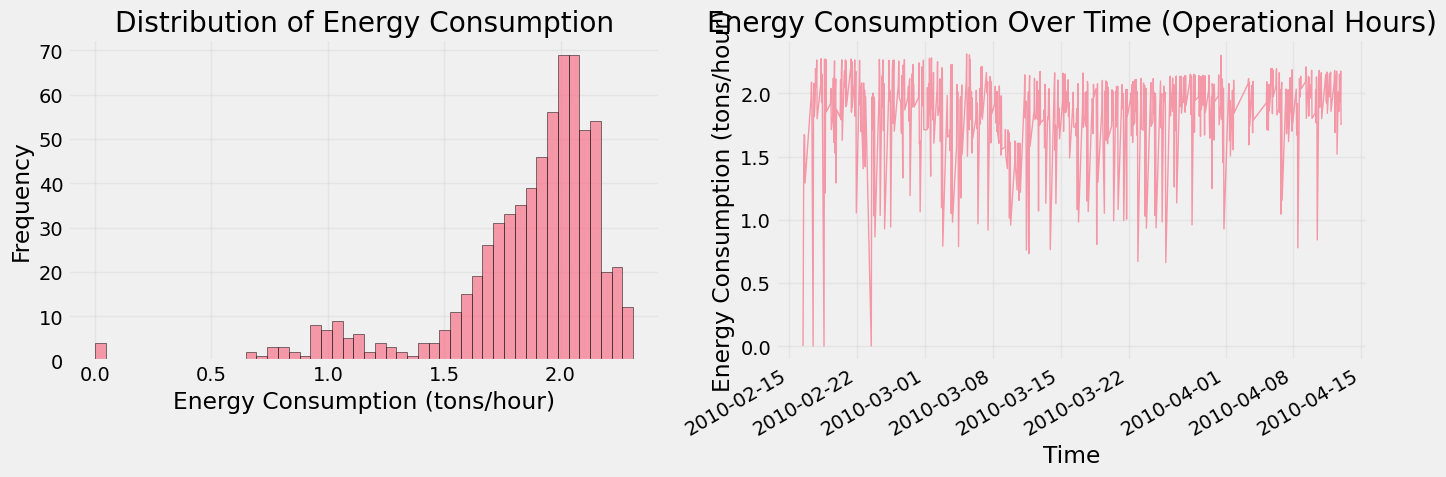

Top 15 features correlated with energy consumption:   ====================
fuel_flow          0.999891
port_pitch         0.921816
avg_pitch          0.914384
water_speed        0.900646
speed_knots        0.899859
starboard_pitch    0.894849
port_rudder        0.699394
speed_ratio        0.638874
fuel_temp          0.387978
wind_speed         0.354093
avg_rudder         0.177979
wind_resistance    0.123646
inclinometer       0.039202
wind_lateral       0.021016
wind_angle        -0.008262
Name: EC_final, dtype: float64


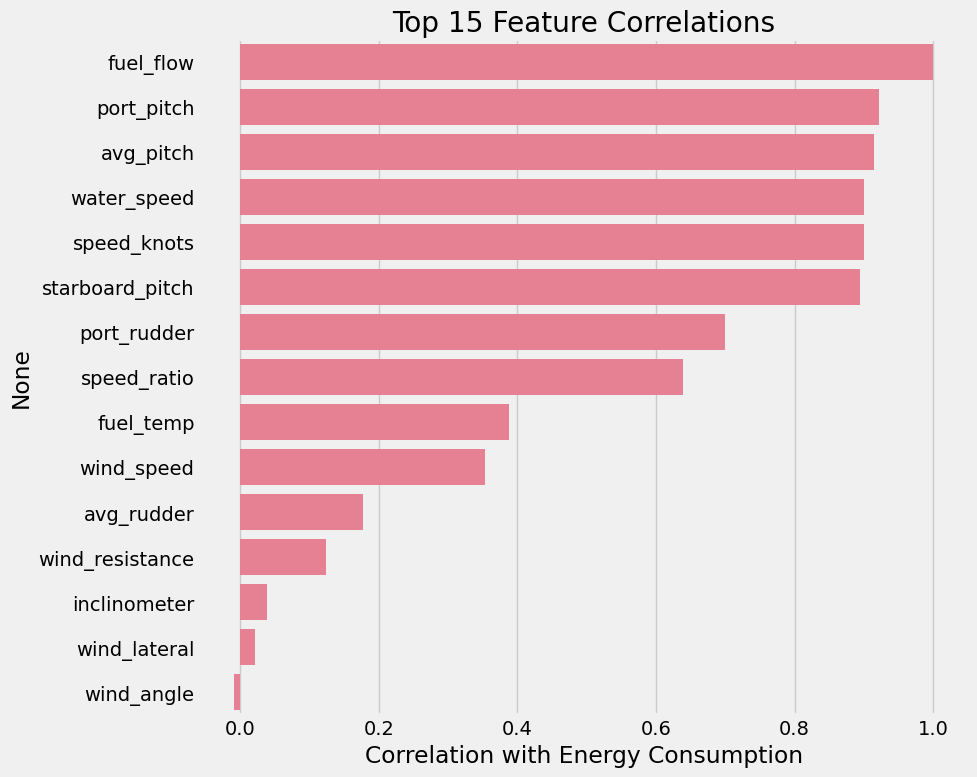

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(master_df['EC_final'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Energy Consumption (tons/hour)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Energy Consumption')
axes[0].grid(True, alpha=0.3)

master_df['EC_final'].plot(ax=axes[1], alpha=0.7, linewidth=1)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Energy Consumption (tons/hour)')
axes[1].set_title('Energy Consumption Over Time (Operational Hours)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

numerical_cols = master_df.select_dtypes(include=[np.number]).columns.tolist()
if 'EC_final' in numerical_cols:
    numerical_cols.remove('EC_final')

correlations = master_df[numerical_cols + ['EC_final']].corr()['EC_final'].sort_values(ascending=False)

pp("\nTop 15 features correlated with energy consumption:")
print(correlations.head(16)[1:])

plt.figure(figsize=(10, 8))
top_features = correlations.head(16).index[1:]
sns.barplot(x=correlations[top_features].values, y=top_features)
plt.xlabel('Correlation with Energy Consumption')
plt.title('Top 15 Feature Correlations')
plt.tight_layout()
plt.show()

In [ ]:
master_df['EC_final'].describe()

,EC_final
count,686.000000
mean,1.853701
std,0.349540
min,0.000000
25%,1.741505
50%,1.951590
75%,2.074019
max,2.311942


In [ ]:

feature_cols = [
    'fuel_temp',
    'speed_knots', 'water_speed', 'heading',
    'port_pitch', 'starboard_pitch',
    'port_rudder', 'starboard_rudder',
    'wind_speed', 'wind_angle', 'inclinometer',
]
feature_cols.extend(engineered_features)

X = master_df[feature_cols].copy()
y = master_df['EC_final'].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())




split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period: {X_test.index.min()} to {X_test.index.max()}")

print("\n" + "="*60)
print("Scaling features...")
print("="*60)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete using RobustScaler")
print(f"Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")


Train set: 514 samples (74.9%)
Test set: 172 samples (25.1%)

Train period: 2010-02-16 10:00:00 to 2010-03-28 17:00:00
Test period: 2010-03-28 18:00:00 to 2010-04-12 22:00:00

Scaling features...
Scaling complete using RobustScaler
Train mean: -0.129724, std: 2.032058
Test mean: -0.038621, std: 1.591824


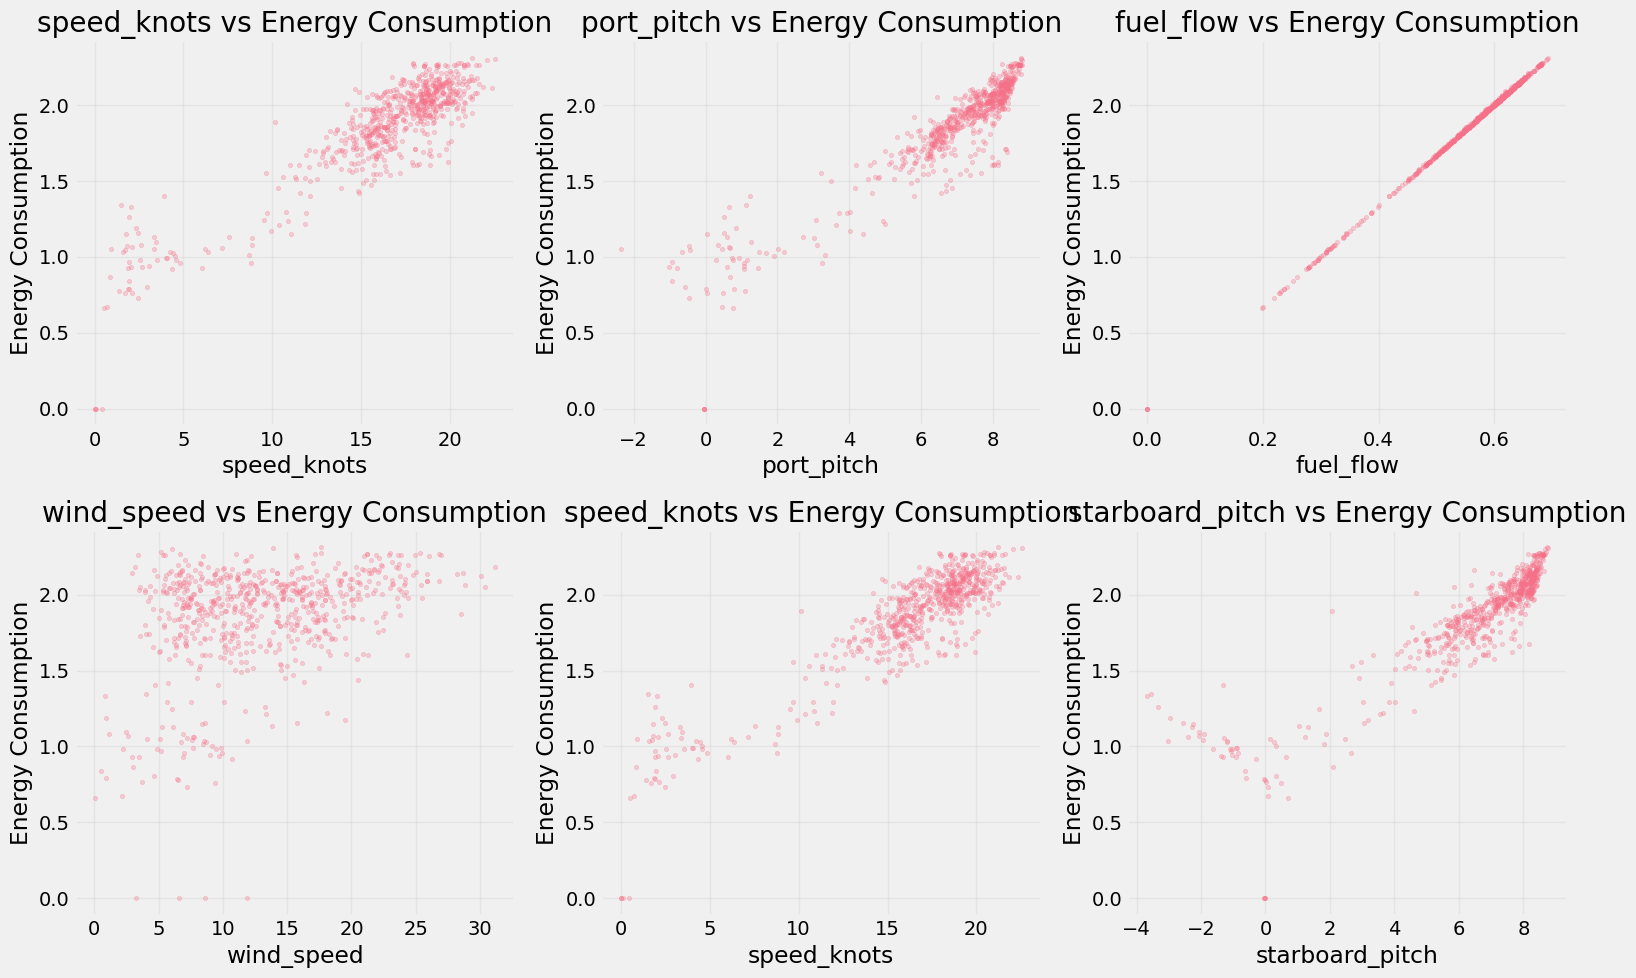

In [ ]:
# Scatter plots of key features vs energy consumption
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

key_features = ['speed_knots', 'port_pitch', 'fuel_flow',
                'wind_speed', 'speed_knots', 'starboard_pitch']

for idx, feature in enumerate(key_features):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(master_df[feature],
                          master_df['EC_final'],
                          alpha=0.3, s=10)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Energy Consumption')
    axes[row, col].set_title(f'{feature} vs Energy Consumption')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Modeling

In [ ]:

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


TRAINING SET:   ====================
====================   Random Forest (Train) Performance Metrics   ====================
====================   R² Score:       0.982478   ====================
====================   RMSE:           0.049493 tons/hour   ====================
====================   MAE:            0.032052 tons/hour   ====================
====================   MAPE:           1.8415%   ====================
====================   Accuracy:       98.1585%   ====================
====================   TEST SET:   ====================
====================   Random Forest (Test) Performance Metrics   ====================
====================   R² Score:       0.887607   ====================
====================   RMSE:           0.082486 tons/hour   ====================
====================   MAE:            0.056460 tons/hour   ====================
====================   MAPE:           3.0040%   ====================
====================   Accuracy:       96.9960%   =====

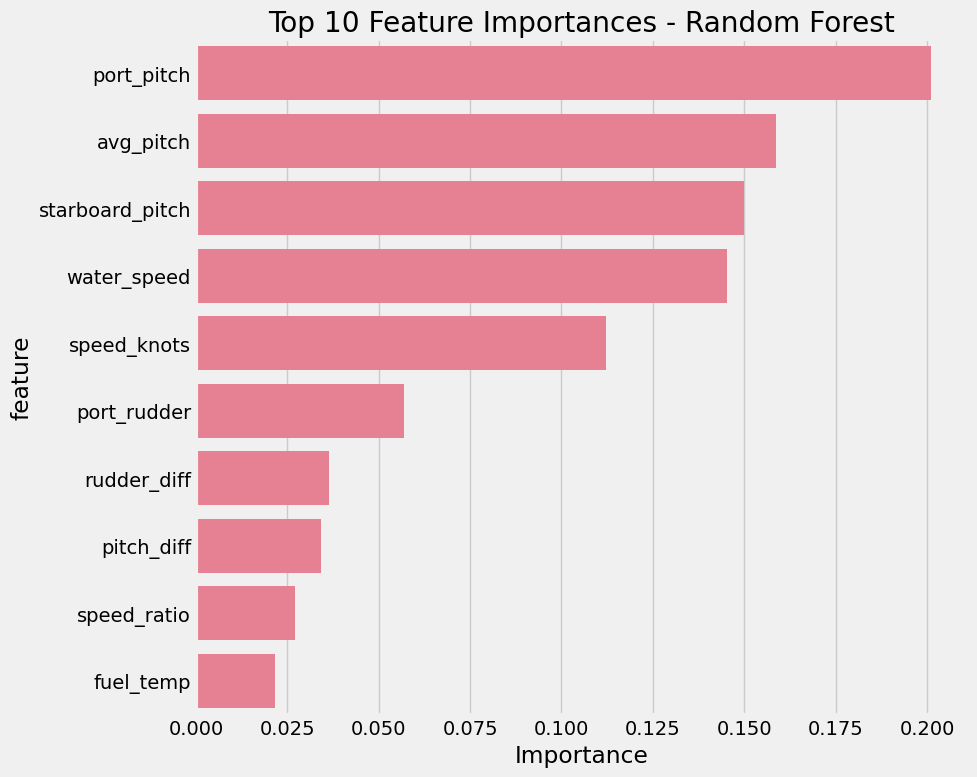

In [ ]:
results = {}
pp("\nTRAINING SET:")
results['RF_train'] = evaluate_model(y_train, y_train_pred_rf, "Random Forest (Train)")

pp("TEST SET:")
results['RF_test'] = evaluate_model(y_test, y_test_pred_rf, "Random Forest (Test)")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

pp("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_rf.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-rmse:0.35788	validation_1-rmse:0.25443
[50]	validation_0-rmse:0.08447	validation_1-rmse:0.09111
[100]	validation_0-rmse:0.07353	validation_1-rmse:0.08947
[150]	validation_0-rmse:0.07301	validation_1-rmse:0.08975
[200]	validation_0-rmse:0.07277	validation_1-rmse:0.08940
[250]	validation_0-rmse:0.07277	validation_1-rmse:0.08927
[299]	validation_0-rmse:0.07242	validation_1-rmse:0.08954

TRAINING SET:
====================   XGBoost (Train) Performance Metrics   ====================
====================   R² Score:       0.962486   ====================
====================   RMSE:           0.072420 tons/hour   ====================
====================   MAE:            0.055450 tons/hour   ====================
====================   MAPE:           3.2087%   ====================
====================   Accuracy:       96.7913%   ====================
TEST SET:
====================   XGBoost (Test) Performance Metrics   ====================
====================   R² Score:   

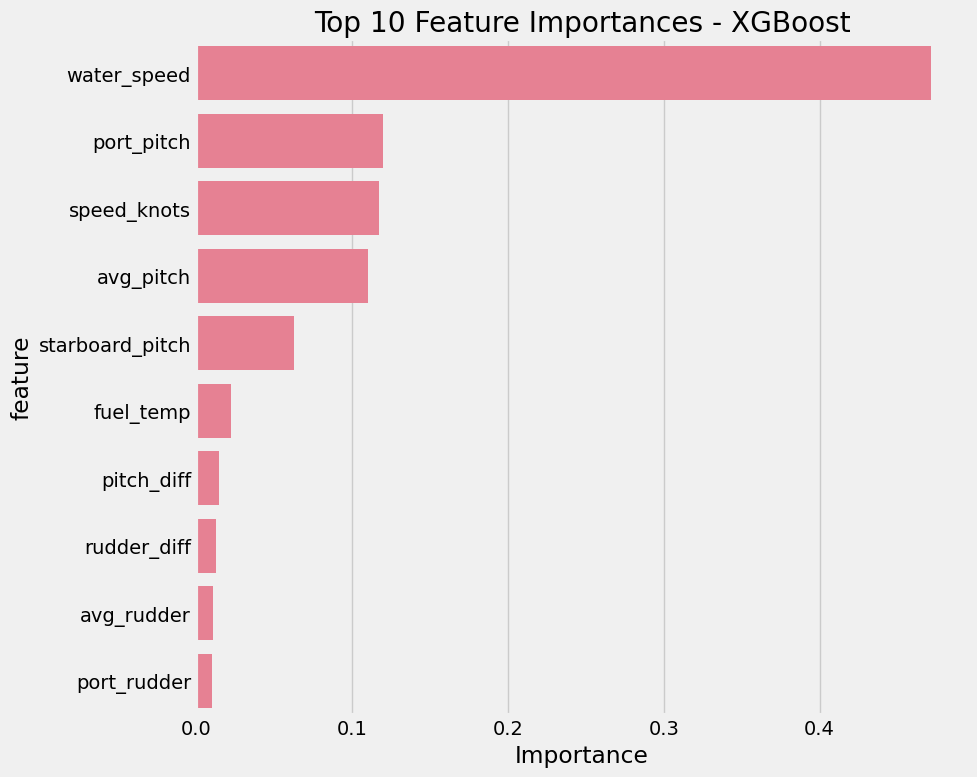

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=50
)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
print("\nTRAINING SET:")
results['XGB_train'] = evaluate_model(y_train, y_train_pred_xgb, "XGBoost (Train)")

print("TEST SET:")
results['XGB_test'] = evaluate_model(y_test, y_test_pred_xgb, "XGBoost (Test)")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_xgb.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

====================   MODEL COMPARISON   ====================

        Model  Train_R2  Test_R2  Train_Accuracy  Test_Accuracy  Test_RMSE  Test_MAE
Random Forest  0.982478 0.887607       98.158462       96.99597   0.082486  0.056460
      XGBoost  0.962486 0.867556       96.791319       96.56689   0.089541  0.063001


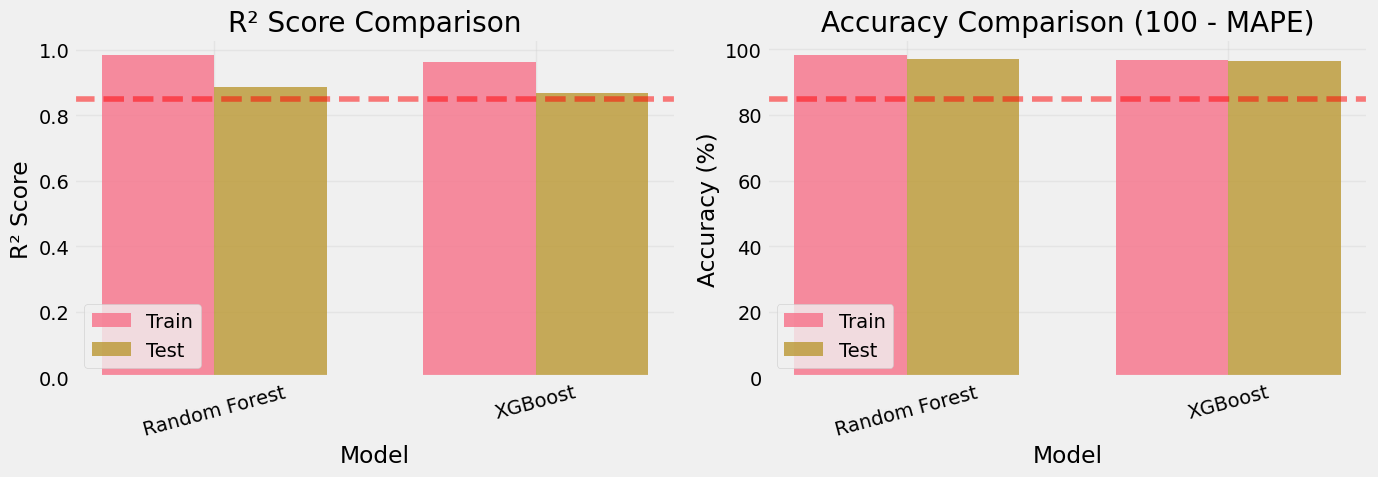

In [ ]:

pp("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Train_R2': [results['RF_train']['r2'], results['XGB_train']['r2']],
    'Test_R2': [results['RF_test']['r2'], results['XGB_test']['r2']],
    'Train_Accuracy': [results['RF_train']['accuracy'], results['XGB_train']['accuracy']],
    'Test_Accuracy': [results['RF_test']['accuracy'], results['XGB_test']['accuracy'],],
    'Test_RMSE': [results['RF_test']['rmse'], results['XGB_test']['rmse']],
    'Test_MAE': [results['RF_test']['mae'], results['XGB_test']['mae']]
})

print("\n" + comparison_df.to_string(index=False))

best_idx = comparison_df['Test_Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_r2 = comparison_df.loc[best_idx, 'Test_R2']
best_acc = comparison_df.loc[best_idx, 'Test_Accuracy']


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Train_R2'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['Test_R2'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.85, color='r', linestyle='--', alpha=0.5, label='Target (85%)')

axes[1].bar(x - width/2, comparison_df['Train_Accuracy'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Test_Accuracy'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Comparison (100 - MAPE)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=85, color='r', linestyle='--', alpha=0.5, label='Target (85%)')

plt.tight_layout()
plt.show()


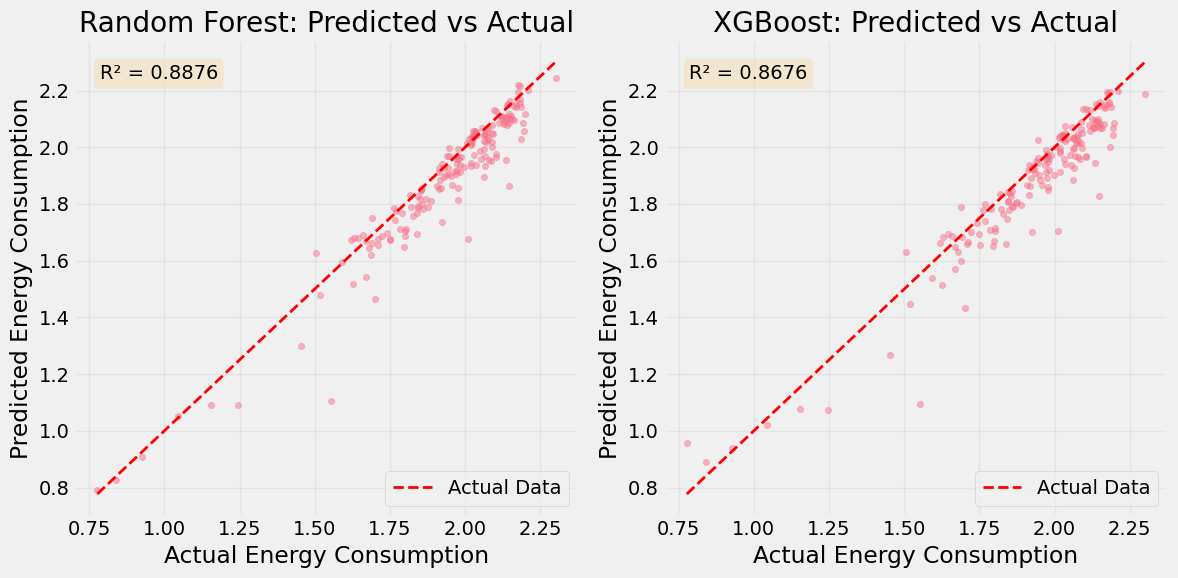

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

models_predictions = [
    ('Random Forest', y_test_pred_rf),
    ('XGBoost', y_test_pred_xgb),
]

for idx, (name, pred) in enumerate(models_predictions):
    col = idx

    axes[col].scatter(y_test, pred, alpha=0.5, s=20)
    axes[col].plot([y_test.min(), y_test.max()],
                        [y_test.min(), y_test.max()],
                        'r--', lw=2, label='Actual Data')
    axes[col].set_xlabel('Actual Energy Consumption')
    axes[col].set_ylabel('Predicted Energy Consumption')
    axes[col].set_title(f'{name}: Predicted vs Actual')
    axes[col].legend()
    axes[col].grid(True, alpha=0.3)

    r2 = r2_score(y_test, pred)
    axes[col].text(0.05, 0.95, f'R² = {r2:.4f}',
                        transform=axes[col].transAxes,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


